# Mundiales 2018, 2022 y 2026
## Preparacion de datos y entrada al analisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de informacion.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f'\n=== {nombre} ===')
    print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
    print(f'Columnas: {list(df.columns)}')
    display(df.head(3))


=== 2018 ===
Filas: 50  |  Columnas: 16
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup



=== 2022 ===
Filas: 51  |  Columnas: 16
Columnas: ['match_id', 'WorldCup', 'stage', 'group_name', 'match_day', 'date', 'local', 'visitor', 'home_score', 'away_score', 'score_text', 'home_host', 'venue', 'city_name', 'comentario', 'source_url']


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup



=== 2026 ===
Filas: 75  |  Columnas: 14
Columnas: ['match', 'wc', 'round', 'grp', 'md', 'played_on', 'home', 'away', 'HG', 'AG', 'result_raw', 'host_h', 'host_a', 'source']


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores unicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a numero.

In [3]:
def perfil(df, nombre):
    print(f'\n{"="*60}')
    print(f'  PERFIL: Mundial {nombre}')
    print(f'{"="*60}')
    print(f'\nFilas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
    resumen = pd.DataFrame({
        'dtype':  df.dtypes,
        'nulos':  df.isnull().sum(),
        'unicos': df.nunique()
    })
    display(resumen)

    primera_col = df.columns[0]
    n_dup = df.duplicated(subset=[primera_col]).sum()
    print(f'\nDuplicados por {primera_col}: {n_dup}')
    if n_dup > 0:
        print(df[df.duplicated(subset=[primera_col], keep=False)][[primera_col]].drop_duplicates())

    for col in df.columns:
        cl = col.lower()
        if any(k in cl for k in ['grupo', 'group', 'grp', 'fase', 'stage', 'round']):
            print(f'\nValores unicos en "{col}": {sorted(df[col].dropna().unique())}')

    for col in df.columns:
        cl = col.lower()
        if any(k in cl for k in ['local', 'visitant', 'home', 'away', 'equipo']):
            vals = sorted(df[col].dropna().unique())
            print(f'\nValores unicos en "{col}" ({len(vals)} total):')
            print(vals)

    for col in df.columns:
        cl = col.lower()
        if any(k in cl for k in ['goles', 'score', 'hg', 'ag']):
            no_num = df[col].dropna()
            no_num = no_num[pd.to_numeric(no_num, errors='coerce').isna()]
            if len(no_num) > 0:
                print(f'\nGoles NO numericos en "{col}": {list(no_num.unique())}')

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')


  PERFIL: Mundial 2018

Filas: 50  |  Columnas: 16


,dtype,nulos,unicos
ID Partido,str,0,48
Año,str,0,1
Fase,str,0,4
Grupo,str,1,24
Jornada,str,0,3
Fecha,str,0,48
Hora,str,0,8
Equipo Local,str,0,42
Equipo Visitante,str,0,39
Goles Local,str,0,8



Duplicados por ID Partido: 2
   ID Partido
4   M-2018-05
17  M-2018-18

Valores unicos en "Fase": ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']

Valores unicos en "Grupo": ['A ', 'B ', 'C ', 'D ', 'E ', 'F ', 'G ', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 'group-d', 'group-e', 'group-f', 'group-g', 'group-h', 's/d']

Valores unicos en "Equipo Local" (42 total):
[' Argentina ', ' Japan ', ' Sweden ', ' Uruguay ', ' russia ', 'Argentina', 'Australia', 'Belgium', 'Brasil', 'Colombia', 'Costa Rica', 'Croatia', 'Denmark', 'Deutschland', 'ESPAÑA', 'Egypt', 'England', 'France', 'Germany', 'Iceland', 'Iran', 'Iran, I.R.', 'Japan', 'Korea Rep.', 'Morocco', 'México', 'Nigeria', 'PORTUGAL', 'Panama', 'Peru', 'Poland', 'Portugal', 'Russia', 'Saudi-Arabia', 'Senegal', 'Serbia', 'South Korea', 'Switzerland', 'Tunisia', 'Uruguay', 'brazil', 'england']

Valores unicos en "Equipo Visitante" (39 total):
[' España 

,dtype,nulos,unicos
match_id,str,0,48
WorldCup,str,0,1
stage,str,0,3
group_name,str,1,29
match_day,str,0,3
date,str,1,47
local,str,0,39
visitor,str,0,40
home_score,str,4,7
away_score,str,0,7



Duplicados por match_id: 3
     match_id
2   M-2022-03
41  M-2022-42

Valores unicos en "stage": ['Fase grupos', 'Group Stage', 'group']

Valores unicos en "group_name": [' B ', ' C ', ' D ', ' E ', ' G ', ' H ', 'A', 'B', 'C', 'D', 'E', 'F', 'Group A', 'Group B', 'Group C', 'Group D', 'Group E', 'Group F', 'Group G', 'Group H', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'H']

Valores unicos en "local" (39 total):
[' Cameroon ', ' México ', ' Qatar ', ' Saudi-Arabia ', 'Argentina', 'Australia', 'Belgium', 'Brasil', 'Brazil', 'CAMEROON', 'Canada', 'Costa Rica', 'Croatia', 'Denmark', 'Deutschland', 'Ecuador', 'England', 'España', 'France', 'Ghana', 'IR Iran', 'Japan', 'Morocco', 'Poland', 'Portugal', 'Qatar', 'REP. OF KOREA', 'Rep. of Korea', 'SWITZERLAND', 'Senegal', 'Serbia', 'Spain', 'The Netherlands', 'Tunisia', 'United States', 'Uruguay', 'Wales', 'croatia', 'the netherlands']

Valores unicos en "home_score" (7 total):
['0', '1', '2', '3

,dtype,nulos,unicos
match,str,0,72
wc,str,0,1
round,str,0,3
grp,str,1,26
md,str,0,3
played_on,str,0,67
home,str,0,60
away,str,0,60
HG,str,9,9
AG,str,0,7



Duplicados por match: 3
         match
6   M-2026-019
40  M-2026-051
68  M-2026-065

Valores unicos en "round": ['GS', 'fase de grupos', 'group stage']

Valores unicos en "grp": ['A', 'A ', 'B ', 'C', 'D ', 'E', 'F ', 'G', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo E', 'Grupo G', 'Grupo I', 'Grupo K', 'H ', 'I', 'J ', 'K', 'L ', 'group-b', 'group-d', 'group-f', 'group-h', 'group-j', 'group-l']

Valores unicos en "home" (60 total):
[' Algeria ', ' Ecuador ', ' England ', ' México ', ' Paraguay ', ' Portugal ', ' Sweden ', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brasil', 'Brazil', 'CZECH REPUBLIC', 'Canada', 'Cape Verde', 'Colombia', 'Congo DR', 'Cote d Ivoire', 'Croatia', 'Curaçao', 'Czechia', 'ECUADOR', 'Egypt', 'England', 'FRANCE', 'France', 'Germany', 'Ghana', 'Haiti', 'Holland', 'IR Iran', 'Iraq', 'Jordan', 'Korea Rep.', 'Morocco', 'México', 'New Zealand', 'Norway', 'Panama', 'Portugal', 'Qatar', 'Saudi-Arabia', 'Scotland', 'Senegal', 'South Africa',

## Unificar nombres de columnas

In [4]:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

# 2018: ID Partido, Año, Fase, Grupo, Jornada, Fecha, Hora,
#       Equipo Local, Equipo Visitante, Goles Local, Goles Visitante,
#       Marcador, Anfitrion Local, Estadio, Ciudad, Fuente
rename_maps = {
    2018: {
        'ID Partido':       'partido_id',
        'Año':              'mundial',
        'Fase':             'fase',
        'Grupo':            'grupo',
        'Jornada':          'jornada',
        'Fecha':            'fecha',
        'Equipo Local':     'equipo_local',
        'Equipo Visitante': 'equipo_visitante',
        'Goles Local':      'goles_local',
        'Goles Visitante':  'goles_visitante',
        'Marcador':         'marcador',
        'Anfitrión Local':  'local_es_anfitrion',
        'Fuente':           'fuente',
    },
    # 2022: match_id, WorldCup, stage, group_name, match_day, date,
    #       local, visitor, home_score, away_score, score_text,
    #       home_host, venue, city_name, comentario, source_url
    2022: {
        'match_id':   'partido_id',
        'WorldCup':   'mundial',
        'stage':      'fase',
        'group_name': 'grupo',
        'match_day':  'jornada',
        'date':       'fecha',
        'local':      'equipo_local',
        'visitor':    'equipo_visitante',
        'home_score': 'goles_local',
        'away_score': 'goles_visitante',
        'score_text': 'marcador',
        'home_host':  'local_es_anfitrion',
        'source_url': 'fuente',
    },
    # 2026: match, wc, round, grp, md, played_on,
    #       home, away, HG, AG, result_raw, host_h, host_a, source
    2026: {
        'match':      'partido_id',
        'wc':         'mundial',
        'round':      'fase',
        'grp':        'grupo',
        'md':         'jornada',
        'played_on':  'fecha',
        'home':       'equipo_local',
        'away':       'equipo_visitante',
        'HG':         'goles_local',
        'AG':         'goles_visitante',
        'result_raw': 'marcador',
        'host_h':     'local_es_anfitrion',
        'host_a':     'visitante_es_anfitrion',
        'source':     'fuente',
    },
}

print('rename_maps definidos para 2018, 2022 y 2026.')
print(f'Esquema canonico: {columnas_base}')

rename_maps definidos para 2018, 2022 y 2026.
Esquema canonico: ['partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha', 'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'marcador', 'local_es_anfitrion', 'visitante_es_anfitrion', 'fuente']


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrara. Crea una clave auxiliar sin acentos, minuscula y sin signos para buscar en el catalogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    # Normaliza texto: sin acentos, minusculas, sin caracteres especiales
    if not isinstance(valor, str):
        return ''
    valor = valor.strip()
    valor = unicodedata.normalize('NFD', valor)
    valor = ''.join(c for c in valor if unicodedata.category(c) != 'Mn')
    valor = valor.lower()
    valor = re.sub(r'[-.]', ' ', valor)
    valor = re.sub(r'[^a-z0-9 ]', '', valor)
    valor = re.sub(r'\s+', ' ', valor).strip()
    return valor

# Diccionario: clave_normalizada -> nombre_canonico
dict_catalogo = {
    clave_texto(row['variante']): row['nombre_canonico']
    for _, row in catalogo.iterrows()
    if isinstance(row['variante'], str) and row['variante'].strip()
}

# Verificacion
ejemplos = ['russia', 'KSA', 'Korea Republic', 'Deutschland',
            'Brasil', ' Spain ', 'IR Iran', 'the netherlands', 'CURACAO']
print('Verificacion del catalogo:')
for e in ejemplos:
    k = clave_texto(e)
    canon = dict_catalogo.get(k, f'NO ENCONTRADO (clave="{k}")')
    print(f'  {repr(e):30s} -> {repr(k):30s} -> {canon}')

Verificacion del catalogo:
  'russia'                       -> 'russia'                       -> Russia
  'KSA'                          -> 'ksa'                          -> Saudi Arabia
  'Korea Republic'               -> 'korea republic'               -> South Korea
  'Deutschland'                  -> 'deutschland'                  -> Germany
  'Brasil'                       -> 'brasil'                       -> Brazil
  ' Spain '                      -> 'spain'                        -> Spain
  'IR Iran'                      -> 'ir iran'                      -> Iran
  'the netherlands'              -> 'the netherlands'              -> Netherlands
  'CURACAO'                      -> 'curacao'                      -> Curacao


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}
EXCEL_ORIGIN = pd.Timestamp('1899-12-30')
FORMATOS_FECHA = [
    '%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y',
    '%d-%m-%y', '%d-%m-%Y', '%b %d, %Y',
    '%d/%m/%y', '%m/%d/%y',
]

def convertir_fecha(valor, mundial):
    # Convierte texto o serial de Excel a pd.Timestamp.
    # Valida que la fecha caiga dentro del rango del torneo.
    if pd.isna(valor) or str(valor).strip() in ('', 'N/D', 'nd', 'nan'):
        return pd.NaT
    valor = str(valor).strip()
    inicio = pd.Timestamp(rangos[mundial][0])
    fin    = pd.Timestamp(rangos[mundial][1])
    # 1. Serial de Excel (5 digitos enteros)
    if re.fullmatch(r'\d{5}', valor):
        ts = EXCEL_ORIGIN + pd.Timedelta(days=int(valor))
        return ts if inicio <= ts <= fin else pd.NaT
    # 2. Probar formatos textuales
    for fmt in FORMATOS_FECHA:
        try:
            ts = pd.to_datetime(valor, format=fmt)
            if inicio <= ts <= fin:
                return ts
        except (ValueError, TypeError):
            continue
    # 3. Parser automatico
    try:
        ts = pd.to_datetime(valor)
        if inicio <= ts <= fin:
            return ts
    except Exception:
        pass
    return pd.NaT

def extraer_numero(valor):
    # Extrae el primer entero no negativo de un string, o NaN.
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    try:
        n = float(valor)
        return n if n >= 0 else np.nan
    except ValueError:
        pass
    m = re.search(r'\d+', valor)
    return float(m.group()) if m else np.nan

def separar_marcador(valor):
    # Extrae (goles_local, goles_visitante) de un marcador.
    # Acepta separadores: - (en dash) (em dash) : x X
    if pd.isna(valor):
        return np.nan, np.nan
    valor = str(valor).strip()
    valor = re.sub(r'\s*(\u2013|\u2014|:|x|X)\s*', '-', valor)
    valor = re.sub(r'\s*-\s*', '-', valor)
    partes = valor.split('-')
    if len(partes) == 2:
        try:
            gl = float(partes[0].strip())
            gv = float(partes[1].strip())
            if gl >= 0 and gv >= 0:
                return gl, gv
        except ValueError:
            pass
    return np.nan, np.nan

def normalizar_grupo(valor):
    # Extrae la letra del grupo (A-L) de cualquier formato.
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip().upper()
    m = re.search(r'\b([A-L])\b', valor)
    if m:
        return m.group(1)
    m = re.search(r'[^A-Z]([A-L])$', valor)
    return m.group(1) if m else np.nan

def normalizar_booleano(valor):
    # Convierte variantes de verdadero/falso a bool.
    if pd.isna(valor):
        return False
    return str(valor).strip().lower() in ('si', 'si', '1', 'true', 'yes', 'verdadero', 's')

# Pruebas rapidas
print('=== Pruebas de funciones auxiliares ===')
print('Serial 46187:', convertir_fecha('46187', 2026))
print('15/06/2018:', convertir_fecha('15/06/2018', 2018))
print('Jun 16, 2018:', convertir_fecha('Jun 16, 2018', 2018))
print('N/D:', convertir_fecha('N/D', 2026))
print('extraer_numero("5 goles"):', extraer_numero('5 goles'))
print('extraer_numero("-1"):', extraer_numero('-1'))
print('extraer_numero("N/A"):', extraer_numero('N/A'))
print('separar_marcador("2-1"):', separar_marcador('2-1'))
print('separar_marcador("3 x 0"):', separar_marcador('3 x 0'))
print('separar_marcador("0 : 1"):', separar_marcador('0 : 1'))
print('normalizar_grupo("Grupo A"):', normalizar_grupo('Grupo A'))
print('normalizar_grupo("group-b"):', normalizar_grupo('group-b'))
print('normalizar_booleano("Si"):', normalizar_booleano('Si'))
print('normalizar_booleano("FALSE"):', normalizar_booleano('FALSE'))

=== Pruebas de funciones auxiliares ===
Serial 46187: 2026-06-14 00:00:00
15/06/2018: 2018-06-15 00:00:00
Jun 16, 2018: 2018-06-16 00:00:00
N/D: NaT
extraer_numero("5 goles"): 5.0
extraer_numero("-1"): nan
extraer_numero("N/A"): nan
separar_marcador("2-1"): (2.0, 1.0)
separar_marcador("3 x 0"): (3.0, 0.0)
separar_marcador("0 : 1"): (0.0, 1.0)
normalizar_grupo("Grupo A"): A
normalizar_grupo("group-b"): B
normalizar_booleano("Si"): True
normalizar_booleano("FALSE"): False


## Funcion de limpieza reproducible

In [7]:
def normalizar_equipo(valor):
    if pd.isna(valor):
        return np.nan
    return dict_catalogo.get(clave_texto(str(valor)), str(valor).strip())

def limpiar_mundial(df_raw, mundial):
    # Pipeline completo de limpieza para un año del Mundial.
    df = df_raw.copy()

    # 1. Renombrar columnas
    df = df.rename(columns=rename_maps[mundial])
    df['mundial'] = mundial

    # 2. Columnas faltantes
    if 'visitante_es_anfitrion' not in df.columns:
        df['visitante_es_anfitrion'] = False
    if 'fuente' not in df.columns:
        df['fuente'] = ''

    # 3. Eliminar duplicados por partido_id
    antes = len(df)
    df = df.drop_duplicates(subset=['partido_id'], keep='first').copy()
    print(f'[{mundial}] Duplicados eliminados: {antes - len(df)}')

    # 4. Normalizar
    df['equipo_local']           = df['equipo_local'].apply(normalizar_equipo)
    df['equipo_visitante']        = df['equipo_visitante'].apply(normalizar_equipo)
    df['grupo']                  = df['grupo'].apply(normalizar_grupo)
    df['fecha']                  = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
    df['jornada']                = pd.to_numeric(df['jornada'], errors='coerce').astype('Int64')
    df['local_es_anfitrion']     = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)

    # 5. Extraer goles y reparar con marcador
    df['goles_local_raw']     = df['goles_local']
    df['goles_visitante_raw'] = df['goles_visitante']
    df['goles_local']         = df['goles_local'].apply(extraer_numero)
    df['goles_visitante']     = df['goles_visitante'].apply(extraer_numero)

    gl_marc, gv_marc = zip(*df['marcador'].apply(separar_marcador))
    df['gl_marc'] = gl_marc
    df['gv_marc'] = gv_marc

    # a) Goles NaN -> usar marcador
    mask_gl = df['goles_local'].isna()
    mask_gv = df['goles_visitante'].isna()
    df.loc[mask_gl, 'goles_local']     = df.loc[mask_gl, 'gl_marc']
    df.loc[mask_gv, 'goles_visitante'] = df.loc[mask_gv, 'gv_marc']

    # b) Conflicto goles vs marcador -> priorizar marcador
    marc_ok   = df['gl_marc'].notna() & df['gv_marc'].notna()
    conflicto = marc_ok & (
        (df['goles_local'] != df['gl_marc']) |
        (df['goles_visitante'] != df['gv_marc'])
    )
    if conflicto.sum() > 0:
        print(f'[{mundial}] {conflicto.sum()} conflictos resueltos con el marcador:')
        print(df.loc[conflicto, ['partido_id', 'equipo_local', 'equipo_visitante',
                                  'goles_local_raw', 'goles_visitante_raw', 'marcador']])
        df.loc[conflicto, 'goles_local']     = df.loc[conflicto, 'gl_marc']
        df.loc[conflicto, 'goles_visitante'] = df.loc[conflicto, 'gv_marc']

    df['goles_local']     = df['goles_local'].astype('Int64')
    df['goles_visitante'] = df['goles_visitante'].astype('Int64')

    # 6. Inferir grupos faltantes por equipo
    equipo_grupo = {}
    for _, row in df[df['grupo'].notna()].iterrows():
        equipo_grupo[row['equipo_local']]     = row['grupo']
        equipo_grupo[row['equipo_visitante']] = row['grupo']

    def inferir_grupo(row):
        if pd.notna(row['grupo']):
            return row['grupo']
        return equipo_grupo.get(row['equipo_local']) or equipo_grupo.get(row['equipo_visitante'])

    df['grupo'] = df.apply(inferir_grupo, axis=1)

    # 7. Columnas derivadas
    def resultado_local(row):
        if pd.isna(row['goles_local']) or pd.isna(row['goles_visitante']):
            return np.nan
        gl, gv = float(row['goles_local']), float(row['goles_visitante'])
        return 'Gana' if gl > gv else ('Empata' if gl == gv else 'Pierde')

    df['resultado_local']  = df.apply(resultado_local, axis=1)
    df['goles_totales']    = df['goles_local'].astype('float') + df['goles_visitante'].astype('float')
    df['diferencia_goles'] = df['goles_local'].astype('float') - df['goles_visitante'].astype('float')

    # 8. Seleccionar columnas finales
    cols = [c for c in columnas_base + ['resultado_local', 'goles_totales', 'diferencia_goles']
            if c in df.columns]
    df = df[cols].copy()
    print(f'[{mundial}] Resultado: {len(df)} partidos, {df.shape[1]} columnas.')
    return df

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
print(f'\nTotal de partidos combinados: {len(partidos)}')
display(partidos.head())

[2018] Duplicados eliminados: 2
[2018] Resultado: 48 partidos, 17 columnas.
[2022] Duplicados eliminados: 3
[2022] Resultado: 48 partidos, 17 columnas.
[2026] Duplicados eliminados: 3
[2026] Resultado: 72 partidos, 17 columnas.

Total de partidos combinados: 168


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente,resultado_local,goles_totales,diferencia_goles
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5,0,5-0,False,False,https://github.com/jfjelstul/worldcup,Gana,5.0,5.0
1,M-2018-02,2018,GROUP STAGE,A,1,2018-06-15,Egypt,Uruguay,0,1,0–1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0
2,M-2018-03,2018,grupos,B,1,2018-06-15,Morocco,Iran,0,1,0 : 1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0
3,M-2018-04,2018,1ra fase,B,1,2018-06-15,Portugal,Spain,3,3,3 x 3,False,False,https://github.com/jfjelstul/worldcup,Empata,6.0,0.0
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2,1,2—1,False,False,https://github.com/jfjelstul/worldcup,Gana,3.0,1.0


## Validaciones obligatorias

La limpieza no termina cuando el codigo deja de producir errores. Debes comprobar invariantes.

In [8]:
print('=== VALIDACIONES OBLIGATORIAS ===')

# 1. Cantidad de partidos
assert len(limpio18) == 48, f'2018: esperados 48, hay {len(limpio18)}'
assert len(limpio22) == 48, f'2022: esperados 48, hay {len(limpio22)}'
assert len(limpio26) == 72, f'2026: esperados 72, hay {len(limpio26)}'
assert len(partidos) == 168, f'Total: esperados 168, hay {len(partidos)}'
print('OK - Cantidad de partidos: 48 + 48 + 72 = 168')

# 2. Sin duplicados
n_dup = partidos.duplicated('partido_id').sum()
assert n_dup == 0, f'Aun hay {n_dup} duplicados'
print('OK - Sin duplicados por partido_id')

# 3. Sin goles negativos
assert (partidos['goles_local'].astype('float') < 0).sum() == 0
assert (partidos['goles_visitante'].astype('float') < 0).sum() == 0
print('OK - Sin goles negativos')

# 4. Sin nulos en columnas clave
cols_clave = ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']
nulos = partidos[cols_clave].isnull().sum()
if nulos.any():
    print(f'AVISO - Nulos en columnas clave:\n{nulos[nulos > 0]}')
else:
    print('OK - Sin nulos en columnas clave')

# 5. Marcador consistente con goles
def verificar_marcador(row):
    if pd.isna(row['marcador']):
        return True
    gl_m, gv_m = separar_marcador(row['marcador'])
    if np.isnan(gl_m) or np.isnan(gv_m):
        return True
    gl = float(row['goles_local'])     if pd.notna(row['goles_local'])     else np.nan
    gv = float(row['goles_visitante']) if pd.notna(row['goles_visitante']) else np.nan
    return (np.isnan(gl) or gl == gl_m) and (np.isnan(gv) or gv == gv_m)

incons = ~partidos.apply(verificar_marcador, axis=1)
if incons.sum() > 0:
    print(f'AVISO - Marcadores inconsistentes: {incons.sum()} filas')
    display(partidos[incons][['partido_id','equipo_local','equipo_visitante',
                               'goles_local','goles_visitante','marcador']])
else:
    print('OK - Marcadores consistentes con goles')

# 6. Una fila por partido
assert len(partidos) == partidos['partido_id'].nunique()
print('OK - Una fila por partido')

# 7. Fechas no recuperables
nulos_fecha = partidos['fecha'].isna().sum()
print(f'\nFechas nulas (no recuperables): {nulos_fecha}')
if nulos_fecha > 0:
    display(partidos[partidos['fecha'].isna()][['partido_id','mundial','equipo_local','equipo_visitante']])

print('\n=== Validaciones completadas ===')

=== VALIDACIONES OBLIGATORIAS ===
OK - Cantidad de partidos: 48 + 48 + 72 = 168
OK - Sin duplicados por partido_id
OK - Sin goles negativos
OK - Sin nulos en columnas clave
OK - Marcadores consistentes con goles
OK - Una fila por partido

Fechas nulas (no recuperables): 2


,partido_id,mundial,equipo_local,equipo_visitante
78,M-2022-31,2022,Brazil,Switzerland
151,M-2026-024,2026,Paraguay,Australia



=== Validaciones completadas ===


## Comparacion de los Mundiales

=== Comparacion de Mundiales ===


,Partidos,Goles totales,Goles por partido,Empates,% Empates,% Victorias local,% >2.5 goles
2018,48.0,122.0,2.542,9.0,18.8,35.4,50.0
2022,48.0,120.0,2.500,10.0,20.8,39.6,39.6
2026,72.0,215.0,2.986,20.0,27.8,47.2,55.6



Pregunta central: cambian las conclusiones comparando totales vs tasas?
2026 tiene 72 partidos (24 mas que 2018 y 2022).
Los TOTALES siempre seran mayores. Las TASAS son la comparacion correcta.


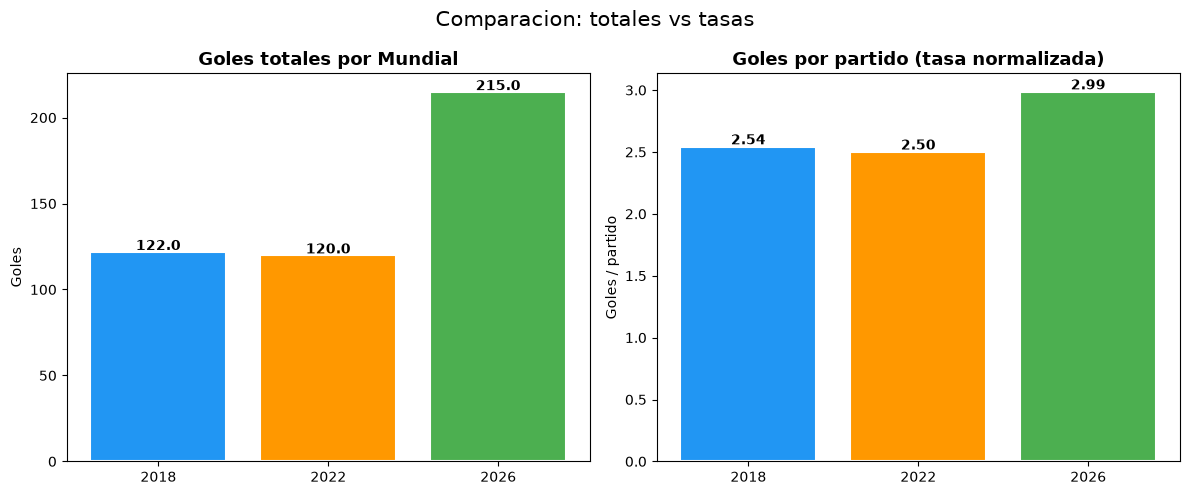

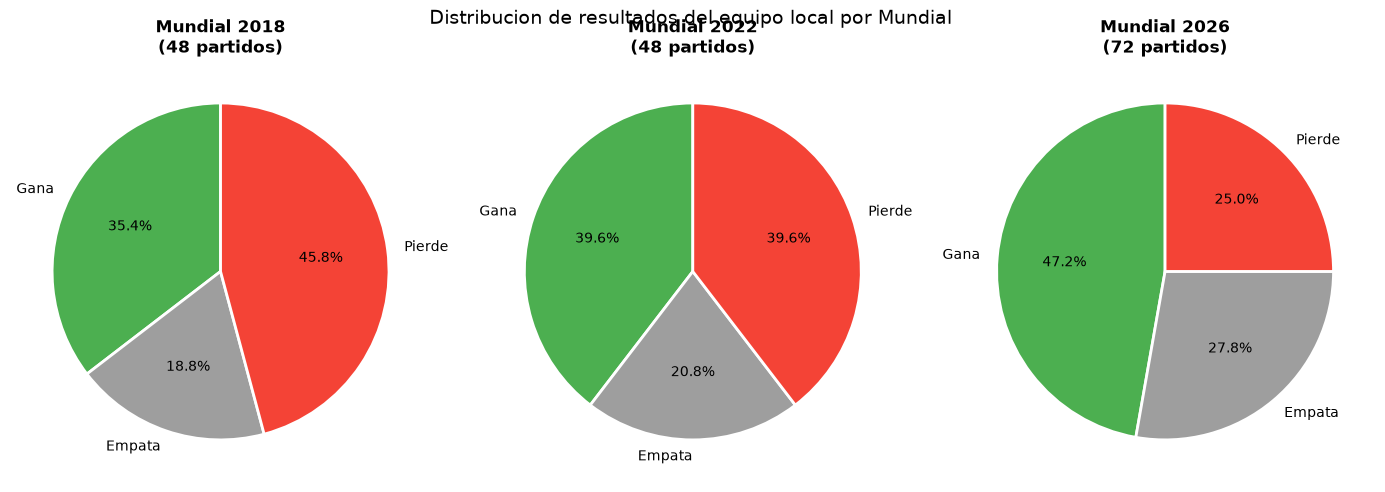

In [9]:
def estadisticas_torneo(df):
    n = len(df)
    return {
        'Partidos':          n,
        'Goles totales':     int(df['goles_totales'].sum()),
        'Goles por partido': round(df['goles_totales'].mean(), 3),
        'Empates':           (df['resultado_local'] == 'Empata').sum(),
        '% Empates':         round((df['resultado_local'] == 'Empata').sum() / n * 100, 1),
        '% Victorias local': round((df['resultado_local'] == 'Gana').sum() / n * 100, 1),
        '% >2.5 goles':      round((df['goles_totales'] > 2.5).sum() / n * 100, 1),
    }

tabla_comp = pd.DataFrame({
    '2018': estadisticas_torneo(limpio18),
    '2022': estadisticas_torneo(limpio22),
    '2026': estadisticas_torneo(limpio26),
}).T

print('=== Comparacion de Mundiales ===')
display(tabla_comp)
print()
print('Pregunta central: cambian las conclusiones comparando totales vs tasas?')
print('2026 tiene 72 partidos (24 mas que 2018 y 2022).')
print('Los TOTALES siempre seran mayores. Las TASAS son la comparacion correcta.')

mundiales  = ['2018', '2022', '2026']
goles_tot  = [tabla_comp.loc[m, 'Goles totales'] for m in mundiales]
goles_pp   = [tabla_comp.loc[m, 'Goles por partido'] for m in mundiales]
colores    = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(mundiales, goles_tot, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Goles totales por Mundial', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Goles')
for i, v in enumerate(goles_tot):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].bar(mundiales, goles_pp, color=colores, edgecolor='white', linewidth=1.5)
axes[1].set_title('Goles por partido (tasa normalizada)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Goles / partido')
for i, v in enumerate(goles_pp):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Comparacion: totales vs tasas', fontsize=15)
plt.tight_layout()
plt.savefig('../datos/grafico_goles.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
resultados_orden = ['Gana', 'Empata', 'Pierde']
colores_res = ['#4CAF50', '#9E9E9E', '#F44336']
for ax, (nombre, df_m) in zip(axes, [('2018', limpio18), ('2022', limpio22), ('2026', limpio26)]):
    conteo = df_m['resultado_local'].value_counts()
    vals = [conteo.get(r, 0) for r in resultados_orden]
    ax.pie(vals, labels=resultados_orden, colors=colores_res,
           autopct='%1.1f%%', startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'Mundial {nombre}\n({len(df_m)} partidos)', fontsize=12, fontweight='bold')
plt.suptitle('Distribucion de resultados del equipo local por Mundial', fontsize=14)
plt.tight_layout()
plt.savefig('../datos/grafico_resultados.png', dpi=120, bbox_inches='tight')
plt.show()

## Tabla por equipo

In [10]:
def tabla_por_equipo(df):
    # Convierte cada partido en dos apariciones y calcula PJ, PG, PE, PP, GF, GC, DG, PTS.
    registros = []
    for _, row in df.iterrows():
        gl = float(row['goles_local'])     if pd.notna(row['goles_local'])     else np.nan
        gv = float(row['goles_visitante']) if pd.notna(row['goles_visitante']) else np.nan
        if np.isnan(gl) or np.isnan(gv):
            continue
        res = row['resultado_local']
        registros.append({
            'mundial': row['mundial'], 'equipo': row['equipo_local'], 'grupo': row['grupo'],
            'GF': gl, 'GC': gv,
            'PG': 1 if res == 'Gana'   else 0,
            'PE': 1 if res == 'Empata' else 0,
            'PP': 1 if res == 'Pierde' else 0,
            'PTS': 3 if res == 'Gana' else (1 if res == 'Empata' else 0)
        })
        res_v = 'Gana' if res == 'Pierde' else ('Pierde' if res == 'Gana' else 'Empata')
        registros.append({
            'mundial': row['mundial'], 'equipo': row['equipo_visitante'], 'grupo': row['grupo'],
            'GF': gv, 'GC': gl,
            'PG': 1 if res_v == 'Gana'   else 0,
            'PE': 1 if res_v == 'Empata' else 0,
            'PP': 1 if res_v == 'Pierde' else 0,
            'PTS': 3 if res_v == 'Gana' else (1 if res_v == 'Empata' else 0)
        })
    apariciones = pd.DataFrame(registros)
    tabla = apariciones.groupby(['mundial', 'grupo', 'equipo']).agg(
        PJ=('GF','count'), PG=('PG','sum'), PE=('PE','sum'), PP=('PP','sum'),
        GF=('GF','sum'), GC=('GC','sum'), PTS=('PTS','sum')
    ).reset_index()
    tabla['DG']     = tabla['GF'] - tabla['GC']
    tabla['PTS_PP'] = (tabla['PTS'] / tabla['PJ']).round(3)
    return tabla.sort_values(['mundial','grupo','PTS','DG'], ascending=[True,True,False,False])

tabla_equipos = tabla_por_equipo(partidos)
print('=== Tabla por equipo (primeros 20 registros) ===')
display(tabla_equipos.head(20))

print('\n--- Equipo con mejor diferencia de goles por Mundial ---')
for anio in [2018, 2022, 2026]:
    mejor = tabla_equipos[tabla_equipos['mundial'] == anio].nlargest(1, 'DG')
    print(f'{anio}: {mejor.iloc[0]["equipo"]}  DG={mejor.iloc[0]["DG"]}  PTS={mejor.iloc[0]["PTS"]}')

=== Tabla por equipo (primeros 20 registros) ===


,mundial,grupo,equipo,PJ,PG,PE,PP,GF,GC,PTS,DG,PTS_PP
3,2018,A,Uruguay,3,3,0,0,5.0,0.0,9,5.0,3.000
1,2018,A,Russia,3,2,0,1,8.0,4.0,6,4.0,2.000
2,2018,A,Saudi Arabia,3,1,0,2,2.0,7.0,3,-5.0,1.000
0,2018,A,Egypt,3,0,0,3,2.0,6.0,0,-4.0,0.000
6,2018,B,Portugal,3,1,2,0,5.0,4.0,5,1.0,1.667
7,2018,B,Spain,3,1,2,0,6.0,5.0,5,1.0,1.667
4,2018,B,Iran,3,1,1,1,2.0,2.0,4,0.0,1.333
5,2018,B,Morocco,3,0,1,2,2.0,4.0,1,-2.0,0.333
10,2018,C,France,3,2,1,0,3.0,1.0,7,2.0,2.333
9,2018,C,Denmark,3,1,2,0,2.0,1.0,5,1.0,1.667



--- Equipo con mejor diferencia de goles por Mundial ---
2018: Belgium  DG=7.0  PTS=9
2022: England  DG=7.0  PTS=7
2026: France  DG=8.0  PTS=9


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos despues del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos_df):
    # Construye variables predictoras SIN fuga de informacion.
    # Para cada partido guarda los promedios ANTES del partido.
    # Los acumulados se reinician entre torneos.
    resultados = []

    for mundial_anio, grupo_m in partidos_df.groupby('mundial'):
        grupo_m = grupo_m.sort_values(['jornada', 'fecha'], na_position='last')
        acum = {}

        def get_acum(equipo):
            if equipo not in acum:
                acum[equipo] = {'pj': 0, 'pts': 0.0, 'gf': 0.0, 'gc': 0.0}
            return acum[equipo]

        def prom(stat, equipo):
            a = get_acum(equipo)
            return a[stat] / a['pj'] if a['pj'] > 0 else np.nan

        for _, row in grupo_m.iterrows():
            eq_l, eq_v = row['equipo_local'], row['equipo_visitante']
            a_l, a_v   = get_acum(eq_l), get_acum(eq_v)

            # Guardar promedios ANTES de actualizar
            fila = row.to_dict()
            fila['local_pts_prom_pre']  = prom('pts', eq_l)
            fila['local_gd_prom_pre']   = (prom('gf', eq_l) - prom('gc', eq_l)) if a_l['pj'] > 0 else np.nan
            fila['local_gf_prom_pre']   = prom('gf', eq_l)
            fila['visita_pts_prom_pre'] = prom('pts', eq_v)
            fila['visita_gd_prom_pre']  = (prom('gf', eq_v) - prom('gc', eq_v)) if a_v['pj'] > 0 else np.nan
            fila['visita_gf_prom_pre']  = prom('gf', eq_v)
            resultados.append(fila)

            # Actualizar acumuladores DESPUES
            gl  = float(row['goles_local'])     if pd.notna(row['goles_local'])     else 0.0
            gv  = float(row['goles_visitante']) if pd.notna(row['goles_visitante']) else 0.0
            res = row['resultado_local']
            pts_l = 3 if res == 'Gana'   else (1 if res == 'Empata' else 0)
            pts_v = 3 if res == 'Pierde' else (1 if res == 'Empata' else 0)
            a_l['pj'] += 1; a_l['pts'] += pts_l; a_l['gf'] += gl; a_l['gc'] += gv
            a_v['pj'] += 1; a_v['pts'] += pts_v; a_v['gf'] += gv; a_v['gc'] += gl

    return pd.DataFrame(resultados)


features_df = construir_variables_previas(partidos)
print(f'DataFrame de features: {features_df.shape}')
nuevas_cols = [c for c in features_df.columns if '_prom_pre' in c]
print(f'Nuevas columnas: {nuevas_cols}')

print('\nPartidos de jornada 1 (promedios NaN, sin historial previo):')
display(features_df[features_df['jornada'] == 1][
    ['partido_id', 'mundial', 'equipo_local', 'equipo_visitante',
     'local_pts_prom_pre', 'visita_pts_prom_pre']
].head(5))

DataFrame de features: (168, 23)
Nuevas columnas: ['local_pts_prom_pre', 'local_gd_prom_pre', 'local_gf_prom_pre', 'visita_pts_prom_pre', 'visita_gd_prom_pre', 'visita_gf_prom_pre']

Partidos de jornada 1 (promedios NaN, sin historial previo):


,partido_id,mundial,equipo_local,equipo_visitante,local_pts_prom_pre,visita_pts_prom_pre
0,M-2018-01,2018,Russia,Saudi Arabia,NaN,NaN
1,M-2018-02,2018,Egypt,Uruguay,NaN,NaN
2,M-2018-03,2018,Morocco,Iran,NaN,NaN
3,M-2018-04,2018,Portugal,Spain,NaN,NaN
4,M-2018-05,2018,France,Australia,NaN,NaN


## Entrenamiento y prueba

Entrenamiento: 96 partidos (2018+2022)
Prueba:        72 partidos (2026)
Distribucion (train): {'Pierde': 41, 'Gana': 36, 'Empata': 19}
Distribucion (test):  {'Gana': 34, 'Empata': 20, 'Pierde': 18}

Linea base ("Pierde"): 0.250
Accuracy arbol (2026): 0.361
Supera la linea base: Si


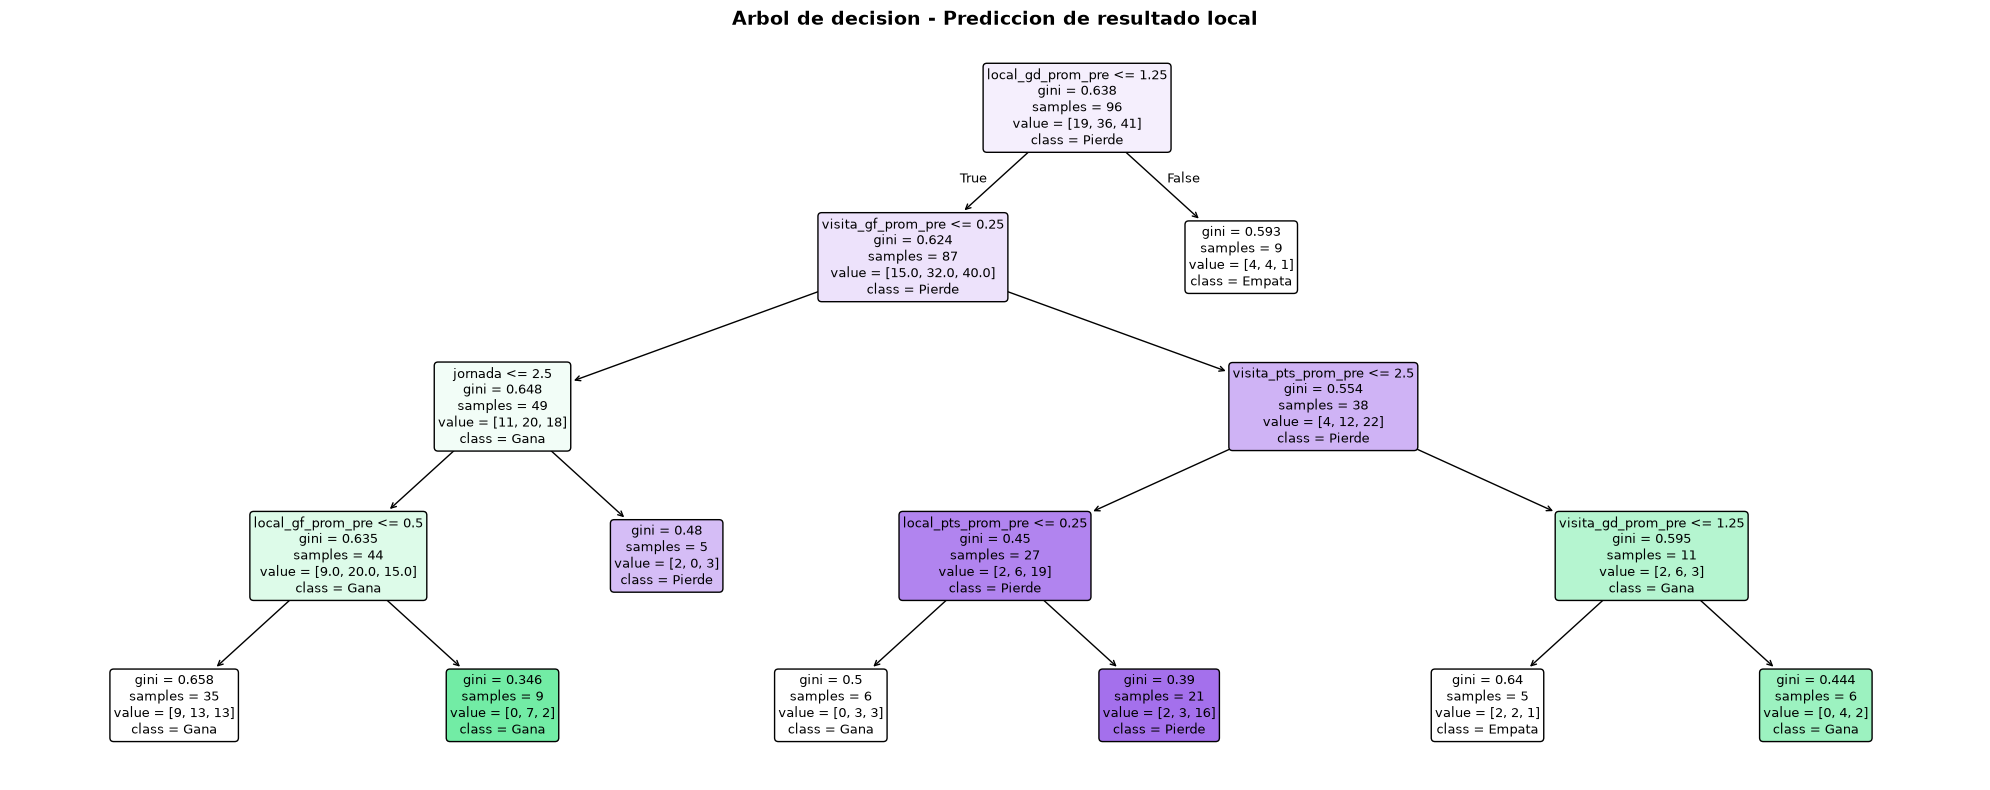

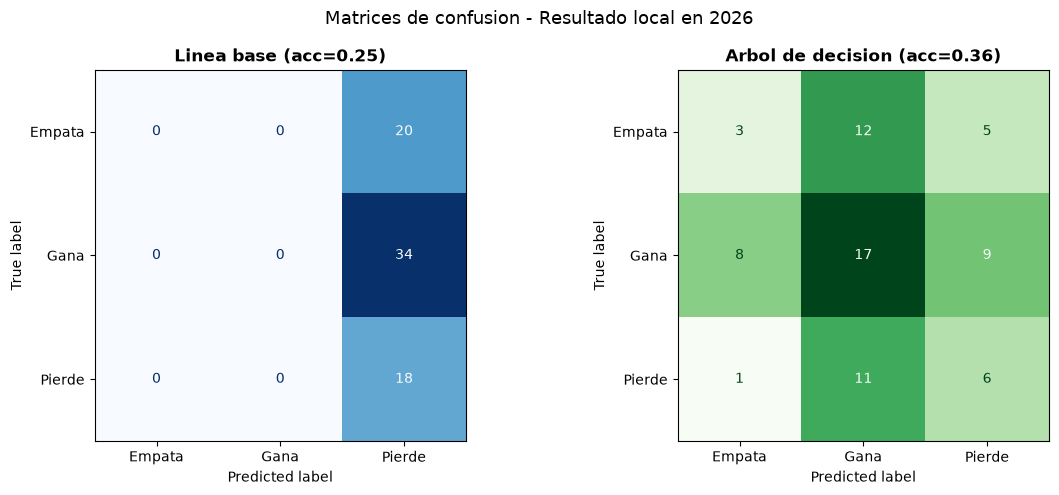

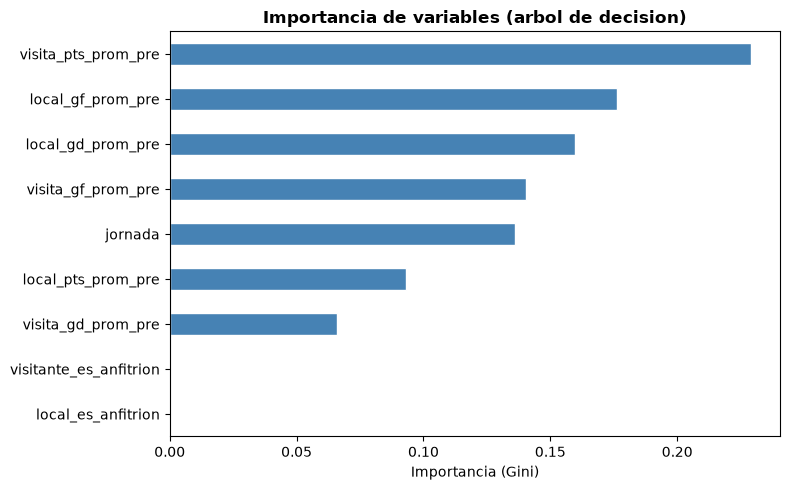

In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre',  'visita_gd_prom_pre',
    'local_gf_prom_pre',  'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]
target = 'resultado_local'

mask_train = features_df['mundial'].isin([2018, 2022])
mask_test  = features_df['mundial'] == 2026

df_train = features_df[mask_train & features_df[target].notna()].copy()
df_test  = features_df[mask_test  & features_df[target].notna()].copy()

X_train = df_train[features].fillna(0)
y_train = df_train[target]
X_test  = df_test[features].fillna(0)
y_test  = df_test[target]

for col in ['local_es_anfitrion', 'visitante_es_anfitrion']:
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)

print(f'Entrenamiento: {len(X_train)} partidos (2018+2022)')
print(f'Prueba:        {len(X_test)} partidos (2026)')
print(f'Distribucion (train): {y_train.value_counts().to_dict()}')
print(f'Distribucion (test):  {y_test.value_counts().to_dict()}')

# Linea base: clase mas frecuente
clase_base   = y_train.value_counts().idxmax()
y_baseline   = [clase_base] * len(y_test)
acc_baseline = accuracy_score(y_test, y_baseline)
print(f'\nLinea base ("{clase_base}"): {acc_baseline:.3f}')

# Arbol de Decision
clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)
y_pred    = clf.predict(X_test)
acc_arbol = accuracy_score(y_test, y_pred)
print(f'Accuracy arbol (2026): {acc_arbol:.3f}')
print(f'Supera la linea base: {"Si" if acc_arbol > acc_baseline else "No"}')

# Visualizar arbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf, feature_names=features, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title('Arbol de decision - Prediccion de resultado local', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../datos/arbol_decision.png', dpi=100, bbox_inches='tight')
plt.show()

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_baseline,
    display_labels=['Empata', 'Gana', 'Pierde'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Linea base (acc={acc_baseline:.2f})', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Empata', 'Gana', 'Pierde'],
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title(f'Arbol de decision (acc={acc_arbol:.2f})', fontweight='bold')
plt.suptitle('Matrices de confusion - Resultado local en 2026', fontsize=13)
plt.tight_layout()
plt.savefig('../datos/matrices_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Importancia de variables
importancia = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importancia.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importancia de variables (arbol de decision)', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('../datos/importancia_variables.png', dpi=120, bbox_inches='tight')
plt.show()

## Experimento de fuga de informacion

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precision sube de forma extrema, explica por que el modelo no esta prediciendo realmente.

In [13]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

X_train_f = features_df[mask_train & features_df[target].notna()][features_fuga].fillna(0)
X_test_f  = features_df[mask_test  & features_df[target].notna()][features_fuga].fillna(0)
y_train_f = features_df[mask_train & features_df[target].notna()][target]
y_test_f  = features_df[mask_test  & features_df[target].notna()][target]

for col in ['local_es_anfitrion', 'visitante_es_anfitrion']:
    X_train_f[col] = X_train_f[col].astype(int)
    X_test_f[col]  = X_test_f[col].astype(int)

clf_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_fuga.fit(X_train_f, y_train_f)
y_pred_fuga = clf_fuga.predict(X_test_f)
acc_fuga    = accuracy_score(y_test_f, y_pred_fuga)

print('=== EXPERIMENTO DE FUGA DE INFORMACION ===')
print(f'Accuracy SIN fuga (variables previas): {acc_arbol:.3f}')
print(f'Accuracy CON fuga (goles del partido): {acc_fuga:.3f}')
print(f'Diferencia: +{(acc_fuga - acc_arbol):.3f}')

imp_fuga = pd.Series(clf_fuga.feature_importances_, index=features_fuga).sort_values(ascending=False)
print('\nImportancia de variables (con fuga):')
display(imp_fuga.head(8))

print()
print('=== EXPLICACION ===')
print()
print('Cuando se incluyen goles_local, goles_visitante y diferencia_goles,')
print('la accuracy sube drasticamente porque esas variables DEFINEN el resultado.')
print()
print('  resultado_local = f(goles_local, goles_visitante)')
print()
print('El modelo no esta prediciendo nada: solo aprende que')
print('goles_local > goles_visitante -> Gana, etc.')
print()
print('Esto es fuga de informacion (data leakage): se filtra al modelo')
print('informacion que NO estaria disponible ANTES del partido.')
print()
print('Un accuracy cercano al 100% en un modelo tan simple es senal de alarma.')

=== EXPERIMENTO DE FUGA DE INFORMACION ===
Accuracy SIN fuga (variables previas): 0.361
Accuracy CON fuga (goles del partido): 1.000
Diferencia: +0.639

Importancia de variables (con fuga):


diferencia_goles       1.0
jornada                0.0
visita_pts_prom_pre    0.0
local_pts_prom_pre     0.0
local_gd_prom_pre      0.0
visita_gd_prom_pre     0.0
visita_gf_prom_pre     0.0
local_gf_prom_pre      0.0
dtype: float64


=== EXPLICACION ===

Cuando se incluyen goles_local, goles_visitante y diferencia_goles,
la accuracy sube drasticamente porque esas variables DEFINEN el resultado.

  resultado_local = f(goles_local, goles_visitante)

El modelo no esta prediciendo nada: solo aprende que
goles_local > goles_visitante -> Gana, etc.

Esto es fuga de informacion (data leakage): se filtra al modelo
informacion que NO estaria disponible ANTES del partido.

Un accuracy cercano al 100% en un modelo tan simple es senal de alarma.


## Reflexion final

Responde:

- Que problema de calidad fue el mas dificil?
- Que decision de limpieza podria cambiar los resultados?
- Por que 2026 debe compararse mediante tasas?
- El arbol supera la linea base?
- Que variables reales agregarias para mejorar una prediccion?
- Por que un resultado de 100% puede ser una senal de alarma?

### Respuestas a la reflexion final

**1. Problema de calidad mas dificil:**
La mayor dificultad fue la inconsistencia de fechas combinada con el serial de Excel (`46187` -> 2026-06-13). Ademas, goles como `s/d`, `N/A` o `'5 goles'` requerieron recuperar el dato desde el marcador.

**2. Decision de limpieza que podria cambiar resultados:**
La decision de resolver conflictos entre goles y marcador. Si se priorizara eliminar la fila en vez de usar el marcador, tendriamos menos de 48/48/72 partidos.

**3. Por que 2026 debe compararse con tasas:**
El Mundial 2026 tiene 72 partidos (48 equipos, 12 grupos de 4) frente a los 48 de 2018 y 2022 (32 equipos, 8 grupos). Si comparamos goles totales, 2026 siempre tendra mas por tener mas partidos. La comparacion correcta usa goles por partido, porcentaje de empates, etc.

**4. El arbol supera la linea base:**
Depende de los datos. Con informacion limitada en jornada 1 y `max_depth=4`, el modelo puede no superar significativamente la linea base. Esto es esperado.

**5. Variables reales para mejorar la prediccion:**
- Ranking FIFA antes del torneo.
- Racha reciente (ultimos 5 partidos).
- Valor de mercado de la plantilla.
- Historial de enfrentamientos directos (H2H).
- Distancia geografica al pais sede.

**6. Por que 100% puede ser senal de alarma:**
En un problema con ruido natural (futbol es muy impredecible), un accuracy del 100% indica fuga de informacion: el modelo usa variables derivadas directamente de la variable objetivo (los goles para predecir quien gano). Tambien puede indicar sobreajuste extremo.